<a href="https://colab.research.google.com/github/zenindust/Lab-1-7/blob/main/Lab1_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tổng hợp Lab 1 → Lab 7



In [1]:
# Cài đặt & import thư viện dùng chung cho toàn bộ notebook
!pip install -q nltk seaborn scipy statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set(style='whitegrid')
print("Đã import xong các thư viện dùng chung.")


Đã import xong các thư viện dùng chung.


# LAB 1 — Thao tác dữ liệu điểm thi đại học



In [2]:
import os

fname = 'dulieuxettuyendaihoc.csv'

if os.path.exists(fname):
    df1 = pd.read_csv(fname)
    # Chuẩn hóa tên cột định danh về 'Id' để đồng nhất với phần code bên dưới
    if 'STT' in df1.columns:
        df1 = df1.rename(columns={'STT': 'Id'})
    print("Đã tìm thấy file thật:", fname)
else:
    print("Không tìm thấy file thật -> sinh dữ liệu mẫu giả lập 100 học sinh")
    np.random.seed(42)
    n = 100
    # File thật có 6 đợt điểm (T1..T6, tương ứng 6 học kỳ của 3 năm cấp 3)
    subjects_all = ['T','L','H','S','V','X','D','N']
    periods = [1,2,3,4,5,6]

    data = {}
    for p in periods:
        for subj in subjects_all:
            col = f'{subj}{p}'
            vals = np.round(np.random.uniform(2, 10, n), 1)
            mask = np.random.rand(n) < 0.05
            vals = vals.astype(object)
            vals[mask] = np.nan
            data[col] = vals

    data['GT'] = np.random.choice(['Nam', 'Nu'], n)
    dt_vals = np.random.choice(['Kinh', 'Hoa', 'Khome', 'Cham'], n, p=[0.85, 0.06, 0.05, 0.04]).astype(object)
    mask_dt = np.random.rand(n) < 0.08
    dt_vals[mask_dt] = np.nan
    data['DT'] = dt_vals

    data['KV'] = np.random.choice(['1', '2', '2NT', '3'], n)
    data['KT'] = np.random.choice(['A', 'A1', 'B', 'C', 'D'], n)
    data['DH1'] = np.round(np.random.uniform(0, 10, n), 2)
    data['DH2'] = np.round(np.random.uniform(0, 10, n), 2)
    data['DH3'] = np.round(np.random.uniform(0, 10, n), 2)

    df1 = pd.DataFrame(data)
    df1.insert(0, 'Id', range(1, n+1))

print(df1.shape)
df1.head(10)


Đã tìm thấy file thật: dulieuxettuyendaihoc.csv
(100, 56)


,Id,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,...,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,5.8,9.0,6.6,8.7,7.2,5.8,7.4,7.4,5.2,6.6,6.9,8.9,8.1,5.8,...,8.1,5.9,7.4,5.6,6.1,5.7,7.9,5.0,7.4,5.0,6.9,5.7,6.5,7.2,8.4,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,3.2,7.2,5.4,6.1,4.7,4.7,4.3,3.8,3.7,3.7,5.2,6.6,5.8,4.4,...,7.6,4.7,3.0,4.6,4.4,4.9,4.3,6.3,6.7,4.4,4.0,5.4,4.0,5.2,5.5,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,6.2,6.1,5.3,7.1,4.0,4.9,2.8,6.3,6.2,5.6,2.5,5.8,5.1,3.7,...,5.3,4.1,4.8,5.1,6.4,5.1,4.0,6.9,3.9,3.2,5.7,6.6,6.8,6.8,4.1,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,5.5,5.5,4.4,6.5,4.9,4.4,5.9,7.3,5.9,4.9,5.7,6.8,6.8,5.4,...,7.3,5.6,6.1,4.9,5.3,4.0,6.2,5.5,5.9,6.5,7.4,5.6,6.6,6.8,6.6,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,5.9,7.5,6.5,6.9,7.6,6.4,7.6,7.6,6.7,6.6,5.7,7.9,7.4,7.3,...,8.6,7.7,6.8,5.4,4.7,5.0,5.1,7.0,7.0,6.3,8.0,6.2,6.8,6.9,6.6,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A
5,6,9.3,7.6,7.9,8.6,7.0,7.3,7.7,7.9,9.6,7.8,8.0,8.7,7.7,8.0,9.2,9.1,7.1,8.5,8.1,8.7,7.2,8.4,7.7,8.2,...,7.3,8.8,8.5,7.6,8.1,9.0,8.4,6.6,6.6,8.2,7.8,6.4,7.2,7.7,7.7,5.7,8.0,7.8,M,NaN,1,1.50,4.00,6.00,D1
6,7,2.8,3.9,5.5,6.9,5.0,7.3,4.6,5.2,4.4,6.7,5.5,7.7,5.0,6.6,6.1,4.6,4.6,4.8,4.4,8.1,5.6,6.0,4.8,3.9,...,6.6,5.6,5.4,4.5,5.0,5.0,5.9,6.1,6.1,4.8,5.3,7.0,6.0,5.7,6.1,6.6,6.0,6.0,F,NaN,2,6.50,6.75,5.25,C
7,8,8.3,6.0,7.6,5.1,7.5,4.7,5.8,7.2,6.7,6.3,6.4,7.1,7.3,6.9,6.1,7.9,8.6,5.7,6.9,6.6,7.4,6.0,5.8,6.5,...,6.7,6.3,8.5,7.0,6.1,6.4,6.6,4.8,7.4,6.9,8.3,6.7,5.6,5.9,7.3,7.1,6.8,7.0,F,NaN,2,3.75,4.50,4.25,D1
8,9,6.5,6.3,7.6,6.0,5.5,7.1,6.3,5.0,7.3,6.8,7.3,6.5,6.4,7.9,7.6,3.7,6.4,6.7,6.7,7.3,6.2,6.1,8.2,5.7,...,8.5,5.7,7.7,7.5,8.8,6.5,5.6,5.6,7.1,6.7,7.7,8.7,8.9,7.5,6.0,9.1,7.9,6.1,F,NaN,1,3.50,3.50,6.75,D1
9,10,7.3,5.9,4.7,7.1,6.7,7.9,6.7,7.7,8.0,6.8,7.6,6.9,6.8,7.8,6.4,7.4,6.5,7.3,6.0,7.8,7.2,7.9,7.1,7.7,...,6.3,7.2,7.5,7.0,8.0,5.9,7.1,6.3,5.1,7.1,6.9,7.0,6.7,7.1,7.7,6.4,6.1,7.8,F,NaN,1,4.00,4.75,5.50,D1


In [ ]:
# Yêu cầu 3: in 10 dòng đầu và 10 dòng cuối
print("10 dòng đầu:")
display(df1.head(10))
print("10 dòng cuối:")
display(df1.tail(10))


In [ ]:
# Yêu cầu 4: Thống kê dữ liệu thiếu cột DT và điền 0 khi thiếu
print("Bảng tần số DT (bao gồm NaN):")
print(df1['DT'].value_counts(dropna=False))
print("\nSố lượng giá trị riêng biệt (không tính NaN):", df1['DT'].nunique())
print("Số dòng thiếu DT:", df1['DT'].isna().sum())

df1['DT'] = df1['DT'].fillna(0)
print("\nSau khi điền 0 cho DT:")
print(df1['DT'].value_counts(dropna=False))


In [ ]:
# Yêu cầu 5: Thống kê + xử lý thiếu cho biến T1 bằng Mean
print("Số dòng thiếu T1:", df1['T1'].isna().sum())
print("Tỉ lệ thiếu T1: {:.2%}".format(df1['T1'].isna().mean()))

mean_T1 = df1['T1'].mean()
df1['T1'] = df1['T1'].fillna(mean_T1)
print("Đã điền giá trị trung bình T1 =", round(mean_T1, 2))


In [ ]:
# Yêu cầu 6: Xử lý dữ liệu thiếu cho toàn bộ các biến điểm số còn lại bằng Mean
# File thật có 6 đợt điểm (mỗi năm cấp 3 có 2 học kỳ) -> T1..T6, L1..L6, ..., N1..N6
subjects_all = ['T','L','H','S','V','X','D','N']
periods_all = [1,2,3,4,5,6]
score_cols = [f'{subj}{p}' for p in periods_all for subj in subjects_all
              if f'{subj}{p}' in df1.columns]

for col in score_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')
    if df1[col].isna().sum() > 0:
        df1[col] = df1[col].fillna(df1[col].mean())

print("Các cột điểm được xử lý:", score_cols)
print("Số giá trị thiếu còn lại trong các cột điểm:", df1[score_cols].isna().sum().sum())


In [ ]:
# Yêu cầu 7: Tạo biến TBM1, TBM2, TBM3
def tbm(row, T, L, H, S, V, X, D, N):
    return (row[T]*2 + row[L] + row[H] + row[S] + row[V]*2 + row[X] + row[D] + row[N]) / 10

df1['TBM1'] = df1.apply(lambda r: tbm(r,'T1','L1','H1','S1','V1','X1','D1','N1'), axis=1)
df1['TBM2'] = df1.apply(lambda r: tbm(r,'T2','L2','H2','S2','V2','X2','D2','N2'), axis=1)
df1['TBM3'] = df1.apply(lambda r: tbm(r,'T6','L6','H6','S6','V6','X6','D6','N6'), axis=1)

df1[['TBM1','TBM2','TBM3']].describe()


In [ ]:
# Yêu cầu 8: Tạo biến xếp loại XL1, XL2, XL3
def xeploai(diem):
    if diem < 5.0:
        return 'Y'
    elif diem < 6.5:
        return 'TB'
    elif diem < 8.0:
        return 'K'
    elif diem < 9.0:
        return 'G'
    else:
        return 'XS'

df1['XL1'] = df1['TBM1'].apply(xeploai)
df1['XL2'] = df1['TBM2'].apply(xeploai)
df1['XL3'] = df1['TBM3'].apply(xeploai)

df1[['TBM1','XL1','TBM2','XL2','TBM3','XL3']].head()


In [ ]:
# Yêu cầu 9: Chuyển thang điểm 10 (VN) sang thang điểm 4 (Mỹ) bằng Min-Max Normalization
def minmax_to_us(series):
    return (series - series.min()) / (series.max() - series.min()) * 4

df1['US_TBM1'] = minmax_to_us(df1['TBM1'])
df1['US_TBM2'] = minmax_to_us(df1['TBM2'])
df1['US_TBM3'] = minmax_to_us(df1['TBM3'])

df1[['TBM1','US_TBM1','TBM2','US_TBM2','TBM3','US_TBM3']].head()


In [ ]:
# Yêu cầu 10: Tạo biến kết quả xét tuyển KQXT dựa trên KT và DH1, DH2, DH3
def kqxt(row):
    if row['KT'] in ['A', 'A1']:
        diem = (row['DH1']*2 + row['DH2'] + row['DH3']) / 4
    elif row['KT'] == 'B':
        diem = (row['DH1'] + row['DH2']*2 + row['DH3']) / 4
    else:
        diem = (row['DH1'] + row['DH2'] + row['DH3']) / 3
    return 1 if diem >= 5.0 else 0

df1['KQXT'] = df1.apply(kqxt, axis=1)
df1['KQXT'].value_counts()


In [4]:
# Yêu cầu 11: Lưu file đã xử lý
df1.to_csv('processed_dulieuxettuyendaihoc.csv', index=False)
print("Đã lưu file processed_dulieuxettuyendaihoc.csv")
df1.head()


Đã lưu file processed_dulieuxettuyendaihoc.csv


,Id,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,...,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,5.8,9.0,6.6,8.7,7.2,5.8,7.4,7.4,5.2,6.6,6.9,8.9,8.1,5.8,...,8.1,5.9,7.4,5.6,6.1,5.7,7.9,5.0,7.4,5.0,6.9,5.7,6.5,7.2,8.4,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,3.2,7.2,5.4,6.1,4.7,4.7,4.3,3.8,3.7,3.7,5.2,6.6,5.8,4.4,...,7.6,4.7,3.0,4.6,4.4,4.9,4.3,6.3,6.7,4.4,4.0,5.4,4.0,5.2,5.5,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,6.2,6.1,5.3,7.1,4.0,4.9,2.8,6.3,6.2,5.6,2.5,5.8,5.1,3.7,...,5.3,4.1,4.8,5.1,6.4,5.1,4.0,6.9,3.9,3.2,5.7,6.6,6.8,6.8,4.1,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,5.5,5.5,4.4,6.5,4.9,4.4,5.9,7.3,5.9,4.9,5.7,6.8,6.8,5.4,...,7.3,5.6,6.1,4.9,5.3,4.0,6.2,5.5,5.9,6.5,7.4,5.6,6.6,6.8,6.6,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,5.9,7.5,6.5,6.9,7.6,6.4,7.6,7.6,6.7,6.6,5.7,7.9,7.4,7.3,...,8.6,7.7,6.8,5.4,4.7,5.0,5.1,7.0,7.0,6.3,8.0,6.2,6.8,6.9,6.6,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A


# LAB 2 — Trình bày & Trực quan hóa dữ liệu



In [5]:
df2 = pd.read_csv('processed_dulieuxettuyendaihoc.csv')
df2.head()


,Id,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,...,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,5.8,9.0,6.6,8.7,7.2,5.8,7.4,7.4,5.2,6.6,6.9,8.9,8.1,5.8,...,8.1,5.9,7.4,5.6,6.1,5.7,7.9,5.0,7.4,5.0,6.9,5.7,6.5,7.2,8.4,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,3.2,7.2,5.4,6.1,4.7,4.7,4.3,3.8,3.7,3.7,5.2,6.6,5.8,4.4,...,7.6,4.7,3.0,4.6,4.4,4.9,4.3,6.3,6.7,4.4,4.0,5.4,4.0,5.2,5.5,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,6.2,6.1,5.3,7.1,4.0,4.9,2.8,6.3,6.2,5.6,2.5,5.8,5.1,3.7,...,5.3,4.1,4.8,5.1,6.4,5.1,4.0,6.9,3.9,3.2,5.7,6.6,6.8,6.8,4.1,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,5.5,5.5,4.4,6.5,4.9,4.4,5.9,7.3,5.9,4.9,5.7,6.8,6.8,5.4,...,7.3,5.6,6.1,4.9,5.3,4.0,6.2,5.5,5.9,6.5,7.4,5.6,6.6,6.8,6.6,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,5.9,7.5,6.5,6.9,7.6,6.4,7.6,7.6,6.7,6.6,5.7,7.9,7.4,7.3,...,8.6,7.7,6.8,5.4,4.7,5.0,5.1,7.0,7.0,6.3,8.0,6.2,6.8,6.9,6.6,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A


## Phần 1: Thống kê dữ liệu

In [7]:
# 1. Sắp xếp DH1 tăng dần
print(df2.sort_values('DH1')[['Id','DH1']].head(10))


    Id   DH1
53  54  1.00
43  44  1.25
5    6  1.50
72  73  1.50
83  84  1.75
87  88  1.75
38  39  2.00
12  13  2.00
79  80  2.00
73  74  2.00


In [8]:
# 2. Sắp xếp DH2 tăng dần theo nhóm giới tính
print(df2.sort_values(['GT','DH2'])[['Id','GT','DH2']].head(10))


    Id GT   DH2
95  96  F  1.50
25  26  F  2.00
24  25  F  2.25
46  47  F  2.25
13  14  F  2.75
21  22  F  3.00
0    1  F  3.25
51  52  F  3.25
8    9  F  3.50
22  23  F  3.50


In [9]:
# 3. Pivot table thống kê DH1 theo KT
def q_stats(x):
    return pd.Series({
        'count': x.count(), 'sum': x.sum(), 'mean': x.mean(), 'median': x.median(),
        'min': x.min(), 'max': x.max(), 'std': x.std(),
        'Q1': x.quantile(0.25), 'Q2': x.quantile(0.5), 'Q3': x.quantile(0.75)
    })

pivot_kt = df2.groupby('KT')['DH1'].apply(q_stats).unstack()
pivot_kt


,count,sum,mean,median,min,max,std,Q1,Q2,Q3
KT,,,,,,,,,,
A,49.0,163.50,3.336735,3.25,1.00,6.50,1.274296,2.2500,3.25,4.250
A1,6.0,17.50,2.916667,3.00,2.00,4.25,0.861201,2.1875,3.00,3.250
B,9.0,29.50,3.277778,3.50,1.75,4.50,0.823905,3.2500,3.50,3.750
C,14.0,79.25,5.660714,5.25,4.75,7.00,0.812209,5.0625,5.25,6.375
D1,22.0,84.25,3.829545,3.75,1.25,6.75,1.370146,3.0000,3.75,4.875


In [10]:
# 4. Pivot table DH1 theo KT và KV
pivot_kt_kv = df2.groupby(['KT','KV'])['DH1'].apply(q_stats).unstack()
pivot_kt_kv


count    sum      mean  median   min   max       std      Q1     Q2  \
KT KV                                                                         
A  1     29.0  93.75  3.232759   3.250  1.00  6.50  1.369194  2.0000  3.250   
   2      9.0  31.75  3.527778   3.500  2.00  6.25  1.427653  2.2500  3.500   
   2NT   11.0  38.00  3.454545   3.500  2.00  4.75  0.913908  2.8750  3.500   
A1 1      2.0   4.75  2.375000   2.375  2.00  2.75  0.530330  2.1875  2.375   
   2NT    4.0  12.75  3.187500   3.250  2.00  4.25  0.921389  2.9375  3.250   
B  1      8.0  25.75  3.218750   3.375  1.75  4.50  0.860207  3.0000  3.375   
   2NT    1.0   3.75  3.750000   3.750  3.75  3.75       NaN  3.7500  3.750   
C  1      8.0  43.50  5.437500   5.250  4.75  7.00  0.728869  5.0000  5.250   
   2      2.0  11.50  5.750000   5.750  5.00  6.50  1.060660  5.3750  5.750   
   2NT    4.0  24.25  6.062500   6.000  5.25  7.00  0.943729  5.2500  6.000   
D1 1     13.0  46.75  3.596154   3.500  1.50  5.75  1.264658  2.7500  3.500   
   2      8.0  33.75  4.218750   4.500  1.25  6.75  1.617082  3.5625  4.500   
   2NT    1.0   3.75  3.750000   3.750  3.75  3.75       NaN  3.7500  3.750   

            Q3  
KT KV           
A  1    4.2500  
   2    4.2500  
   2NT  4.1250  
A1 1    2.5625  
   2NT  3.5000  
B  1    3.5625  
   2NT  3.7500  
C  1    5.4375  
   2    6.1250  
   2NT  6.8125  
D1 1    4.2500  
   2    5.0000  
   2NT  3.7500

In [ ]:
# 5. Pivot table DH1 theo KT, KV, DT
pivot_kt_kv_dt = df2.groupby(['KT','KV','DT'])['DH1'].apply(q_stats).unstack()
pivot_kt_kv_dt.head(15)


## Phần 2: Trình bày dữ liệu

Tần số:
 GT
M    52
F    48
Name: count, dtype: int64

Tần suất:
 GT
M    0.52
F    0.48
Name: proportion, dtype: float64


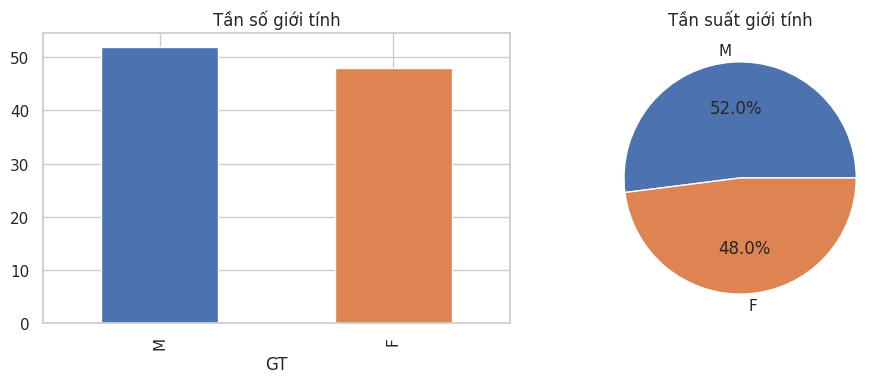

In [11]:
# 1. Biến GT: bảng tần số/tần suất, biểu đồ cột + biểu đồ tròn
freq_gt = df2['GT'].value_counts()
rate_gt = df2['GT'].value_counts(normalize=True)
print("Tần số:\n", freq_gt)
print("\nTần suất:\n", rate_gt)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
freq_gt.plot(kind='bar', ax=ax[0], color=['#4C72B0','#DD8452'])
ax[0].set_title('Tần số giới tính')
rate_gt.plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Tần suất giới tính')
ax[1].set_ylabel('')
plt.tight_layout(); plt.show()


In [ ]:
# 2. Trình bày US_TBM1, US_TBM2, US_TBM3
print(df2[['US_TBM1','US_TBM2','US_TBM3']].describe())
df2[['US_TBM1','US_TBM2','US_TBM3']].hist(figsize=(12,3), layout=(1,3))
plt.tight_layout(); plt.show()


In [ ]:
# 3. Biến DT với học sinh nam
print(df2[df2['GT']=='Nam']['DT'].value_counts())


In [ ]:
# 4. Biến KV với hs nam, dân tộc Kinh, DH1>=5 & DH2>=4 & DH3>=4
# Lưu ý: đề bài không quy định rõ mã số nào trong cột DT tương ứng với dân tộc "Kinh".
# Trong file dữ liệu thật, DT là mã số (ví dụ 1, 6, hoặc 0 sau khi điền thiếu ở Lab 1).
# Mặc định bên dưới giả định DT_KINH_CODE = 1 (giá trị phổ biến nhất) -> hãy chỉnh lại nếu
# giáo viên cung cấp bảng mã dân tộc khác.
DT_KINH_CODE = 1

cond = (df2['GT']=='Nam') & (df2['DT']==DT_KINH_CODE) & (df2['DH1']>=5.0) & (df2['DH2']>=4.0) & (df2['DH3']>=4.0)
print(df2[cond]['KV'].value_counts())


In [ ]:
# 5. DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT
cond2 = (df2['KV']=='2NT') & (df2['DH1']>=5.0) & (df2['DH2']>=5.0) & (df2['DH3']>=5.0)
print(df2[cond2][['Id','DH1','DH2','DH3','KV']])


## Phần 3: Trực quan hóa dữ liệu theo nhóm phân loại

In [ ]:
# 1. Học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
nu = df2[df2['GT']=='Nu']
melt_xl = nu.melt(value_vars=['XL1','XL2','XL3'], var_name='Nhom', value_name='XepLoai')
ct = pd.crosstab(melt_xl['Nhom'], melt_xl['XepLoai'])
order = ['Y','TB','K','G','XS']
ct = ct.reindex(columns=[c for c in order if c in ct.columns])
ct.plot(kind='bar', stacked=False, figsize=(8,5))
plt.title('Số lượng học sinh nữ theo xếp loại (XL1, XL2, XL3) - unstacked')
plt.ylabel('Số lượng'); plt.show()


In [ ]:
# 2. KQXT trên nhóm khối thi A, A1, B thuộc khu vực 1, 2
cond3 = df2['KT'].isin(['A','A1','B']) & df2['KV'].isin(['1','2'])
sub = df2[cond3]
sns.countplot(data=sub, x='KT', hue='KQXT')
plt.title('KQXT theo khối thi A, A1, B (khu vực 1, 2)')
plt.show()


In [ ]:
# 3. Số lượng thí sinh từng khu vực theo từng nhóm khối thi
sns.countplot(data=df2, x='KT', hue='KV')
plt.title('Số lượng thí sinh theo khu vực & khối thi')
plt.show()


In [ ]:
# 4. Số lượng thí sinh đậu/rớt theo từng nhóm khối thi
sns.countplot(data=df2, x='KT', hue='KQXT')
plt.title('Đậu/Rớt theo khối thi'); plt.show()


In [ ]:
# 5. Số lượng thí sinh đậu/rớt theo từng nhóm khu vực
sns.countplot(data=df2, x='KV', hue='KQXT')
plt.title('Đậu/Rớt theo khu vực'); plt.show()


In [ ]:
# 6. Số lượng thí sinh đậu/rớt theo từng nhóm dân tộc
sns.countplot(data=df2, x='DT', hue='KQXT')
plt.title('Đậu/Rớt theo dân tộc'); plt.xticks(rotation=45); plt.show()


In [ ]:
# 7. Số lượng thí sinh đậu/rớt theo từng nhóm giới tính
sns.countplot(data=df2, x='GT', hue='KQXT')
plt.title('Đậu/Rớt theo giới tính'); plt.show()


## Phần 4: Trực quan hóa dữ liệu nâng cao

In [ ]:
# 1. Biểu đồ đường Simple cho T1 (đếm theo giá trị, sắp xếp theo T1)
t1_counts = df2['T1'].round(1).value_counts().sort_index()
plt.figure(figsize=(10,4))
plt.plot(t1_counts.index, t1_counts.values, marker='o')
plt.xlabel('T1'); plt.ylabel('Count'); plt.title('Biểu đồ đường Simple - T1')
plt.xticks(rotation=90); plt.show()


In [ ]:
# 2. Tạo biến phân loại phanlopt1 cho T1
def phanloai_t1(v):
    if v < 5: return 'Kem'
    elif v < 7: return 'Trungbinh'
    elif v < 8: return 'Kha'
    else: return 'Gioi'

df2['phanlopT1'] = df2['T1'].apply(phanloai_t1)


In [ ]:
# 3. Bảng tần số cho phanlopT1
print(df2['phanlopT1'].value_counts())


In [ ]:
# 4. Biểu đồ đường Multiple Line cho T1 theo phanlopT1
plt.figure(figsize=(10,5))
for grp, sub in df2.groupby('phanlopT1'):
    counts = sub['T1'].round(1).value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker='o', label=grp)
plt.legend(title='PhanlopT1'); plt.xlabel('T1'); plt.ylabel('Count')
plt.title('Multiple Line - T1 theo phân lớp'); plt.xticks(rotation=90); plt.show()


In [ ]:
# 5. Biểu đồ Drop-line cho T1 theo phanlopT1
plt.figure(figsize=(12,5))
colors = {'Gioi':'blue','Kem':'green','Kha':'olive','Trungbinh':'purple'}
for grp, sub in df2.groupby('phanlopT1'):
    counts = sub['T1'].round(1).value_counts().sort_index()
    plt.vlines(counts.index, 0, counts.values, color=colors.get(grp,'gray'))
    plt.scatter(counts.index, counts.values, label=grp, facecolors='none',
                edgecolors=colors.get(grp,'gray'))
plt.legend(title='PhanlopT1'); plt.xlabel('T1'); plt.ylabel('Count')
plt.title('Drop-line - T1 theo phân lớp'); plt.xticks(rotation=90); plt.show()


## Phần 5: Mô tả dữ liệu và khảo sát dạng phân phối

In [ ]:
# 1. Mô tả và khảo sát phân phối cho T1
from scipy import stats

print(df2['T1'].describe())
print("Skewness:", df2['T1'].skew())
print("Kurtosis:", df2['T1'].kurt())

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df2['T1'], ax=axes[0]); axes[0].set_title('Box-plot T1')
sns.histplot(df2['T1'], kde=True, ax=axes[1]); axes[1].set_title('Histogram T1')
stats.probplot(df2['T1'], dist='norm', plot=axes[2]); axes[2].set_title('QQ-plot T1')
plt.tight_layout(); plt.show()


In [ ]:
# 2. Mô tả và khảo sát phân phối T1 theo phanlopT1
groups = df2['phanlopT1'].unique()
fig, axes = plt.subplots(len(groups), 3, figsize=(15, 4*len(groups)))
for i, g in enumerate(groups):
    sub = df2[df2['phanlopT1']==g]['T1']
    sns.boxplot(y=sub, ax=axes[i,0]); axes[i,0].set_title(f'Box-plot T1 - {g}')
    sns.histplot(sub, kde=True, ax=axes[i,1]); axes[i,1].set_title(f'Histogram T1 - {g}')
    stats.probplot(sub, dist='norm', plot=axes[i,2]); axes[i,2].set_title(f'QQ-plot T1 - {g}')
plt.tight_layout(); plt.show()


In [ ]:
# 3. Tương quan giữa DH1 và T1
print("Covariance:", df2[['DH1','T1']].cov().iloc[0,1])
print("Correlation:", df2[['DH1','T1']].corr().iloc[0,1])

plt.figure(figsize=(6,5))
sns.scatterplot(data=df2, x='T1', y='DH1')
plt.title('Scatter: DH1 theo T1'); plt.show()


In [ ]:
# 4. Tương quan DH1 - T1 theo từng nhóm khu vực
sns.lmplot(data=df2, x='T1', y='DH1', hue='KV', height=5, aspect=1.3, scatter_kws={'alpha':0.6})
plt.title('DH1 theo T1, phân nhóm khu vực'); plt.show()


In [ ]:
# 5. Tương quan giữa DH1, DH2, DH3
print("Ma trận tương quan:")
print(df2[['DH1','DH2','DH3']].corr())

sns.pairplot(df2[['DH1','DH2','DH3']])
plt.suptitle('Scatter matrix DH1, DH2, DH3', y=1.02)
plt.show()


# LAB 3 — Làm sạch dữ liệu cơ bản (`patient_heart_rate.csv`)



In [ ]:
# Vấn đề 1: thiếu header -> thêm tên cột
column_names = ["Id", "Name", "Age", "Weight", "m0006", "m0612", "m1218", "f0006", "f0612", "f1218"]
df3 = pd.read_csv("patient_heart_rate.csv", names=column_names)
df3.head()


In [ ]:
# Vấn đề 2: cột Name gộp Firstname + Lastname -> tách ra 2 cột
df3[['Firstname','Lastname']] = df3['Name'].str.split(expand=True)
df3 = df3.drop('Name', axis=1)
df3.head()


In [ ]:
# Vấn đề 3: cột Weight không đồng nhất đơn vị (kg / lbs) -> chuẩn hóa về kg
weight = df3['Weight']
for i in range(len(weight)):
    if pd.isna(weight[i]):
        continue
    x = str(weight[i])
    if 'lbs' in x:
        x = x[:-3]
        y = int(float(x) / 2.2)
        weight[i] = str(y) + 'kgs'

df3['Weight'] = weight
df3.head()


In [ ]:
# Vấn đề 4: xóa dòng hoàn toàn trống (NaN)
print("Số dòng trước khi xóa:", len(df3))
df3.dropna(how='all', inplace=True)
print("Số dòng sau khi xóa:", len(df3))


In [ ]:
# Vấn đề 5: xóa dòng trùng lặp hoàn toàn theo Firstname, Lastname, Age, Weight
before = len(df3)
df3 = df3.drop_duplicates(subset=['Firstname','Lastname','Age','Weight'])
print(f"Trước: {before} dòng -> Sau: {len(df3)} dòng")


In [ ]:
# Vấn đề 6: loại bỏ ký tự non-ASCII trong Firstname, Lastname
df3['Firstname'] = df3['Firstname'].replace({r'[^\x00-\x7F]+': ''}, regex=True)
df3['Lastname'] = df3['Lastname'].replace({r'[^\x00-\x7F]+': ''}, regex=True)
df3.head()


In [ ]:
# Vấn đề 7: Missing values ở Age, Weight, Heart Rate
print("Số dòng thiếu Age:", df3['Age'].isna().sum())
print("Số dòng thiếu Weight:", df3['Weight'].astype(str).eq('nan').sum() + df3['Weight'].isna().sum())

# Nếu thiếu cả Age và Weight -> xóa dòng
mask_both_missing = df3['Age'].isna() & df3['Weight'].isna()
df3 = df3[~mask_both_missing].reset_index(drop=True)

# Age còn thiếu -> thay bằng mean
mean_age = df3['Age'].mean()
df3['Age'] = df3['Age'].fillna(mean_age)
print("Đã điền mean Age =", round(mean_age,1))
df3.head()


In [ ]:
# Vấn đề 8: tách cột "m0006" dạng {sex}{mmdd} thành PulseRate, Sex, Time
id_vars = ['Id','Age','Weight','Firstname','Lastname']
df3_melt = df3.melt(id_vars=id_vars, value_name='PulseRate', var_name='sex_and_time')
df3_melt = df3_melt.sort_values(id_vars)

tmp = df3_melt['sex_and_time'].str.extract(r'(\D)(\d{2})(\d{2})')
tmp.columns = ['Sex', 'hours_lower', 'hours_upper']
tmp['Time'] = tmp['hours_lower'] + '-' + tmp['hours_upper']

df3_final = pd.concat([df3_melt.reset_index(drop=True), tmp.reset_index(drop=True)], axis=1)
df3_final = df3_final.drop(['sex_and_time','hours_lower','hours_upper'], axis=1)
df3_final.head(15)


In [ ]:
# Yêu cầu 11: khảo sát & xử lý dữ liệu thiếu ở PulseRate (chuỗi phương pháp thay thế thứ tự)
df3_final['PulseRate'] = pd.to_numeric(df3_final['PulseRate'], errors='coerce')
print("Tỉ lệ thiếu PulseRate: {:.2%}".format(df3_final['PulseRate'].isna().mean()))

df3_final = df3_final.sort_values(['Id','Time']).reset_index(drop=True)

def fill_pulse(df):
    df = df.copy()
    global_mean = df['PulseRate'].mean()
    for pid, grp in df.groupby('Id'):
        idxs = grp.index.tolist()
        vals = df.loc[idxs, 'PulseRate'].tolist()
        for pos, idx in enumerate(idxs):
            if pd.isna(vals[pos]):
                prev_v = vals[pos-1] if pos-1 >= 0 else np.nan
                next_v = vals[pos+1] if pos+1 < len(vals) else np.nan
                if not pd.isna(prev_v) and not pd.isna(next_v):
                    df.loc[idx,'PulseRate'] = (prev_v+next_v)/2
                elif not pd.isna(prev_v):
                    df.loc[idx,'PulseRate'] = prev_v
                elif not pd.isna(next_v):
                    df.loc[idx,'PulseRate'] = next_v
                else:
                    person_mean = grp['PulseRate'].mean()
                    if not pd.isna(person_mean):
                        df.loc[idx,'PulseRate'] = person_mean
                    else:
                        sex_mean = df[df['Sex']==df.loc[idx,'Sex']]['PulseRate'].mean()
                        df.loc[idx,'PulseRate'] = sex_mean if not pd.isna(sex_mean) else global_mean
    return df

df3_final = fill_pulse(df3_final)
print("Số giá trị thiếu còn lại:", df3_final['PulseRate'].isna().sum())


In [ ]:
# Yêu cầu 12: rút gọn dữ liệu phù hợp, reindex và lưu file
df3_final = df3_final.reset_index(drop=True)
df3_final.to_csv('patient_heart_rate_clean.csv', index=False)
print("Đã lưu patient_heart_rate_clean.csv")
df3_final.head(15)


---
# LAB 4 — Chuẩn bị dữ liệu Titanic (`titanic_disaster.csv`)

## Phần 1: Data Cleansing & Feature Engineering


In [ ]:
def load_data(path='titanic_disaster.csv'):
    return pd.read_csv(path)

df4 = load_data()
df4.head(10)


In [ ]:
# 2. Thống kê dữ liệu thiếu + heatmap
missing = df4.isna().sum()
print(missing[missing > 0])

plt.figure(figsize=(10,5))
sns.heatmap(df4.isna(), cbar=False, cmap='viridis')
plt.title('Heatmap dữ liệu thiếu - Titanic')
plt.show()
print("""Nhận xét: Age thiếu khá nhiều (~20%), Cabin thiếu rất nhiều (>75%),
Embarked chỉ thiếu vài dòng (có thể xử lý bằng mode).""")


In [ ]:
# 3. Tách cột Name thành firstName, secondName; xóa cột Name
name_split = df4['Name'].str.split(',', n=1, expand=True)
df4['firstName'] = name_split[0].str.strip()
df4['secondName'] = name_split[1].str.strip()
df4 = df4.drop('Name', axis=1)
df4[['firstName','secondName']].head()


In [ ]:
# 4. Rút gọn cột Sex: male -> M, female -> F
df4['Sex'] = df4['Sex'].map({'male':'M', 'female':'F'})
df4['Sex'].value_counts()


In [ ]:
# 5a. Box-plot Age theo Pclass để quyết định cách thay thế
plt.figure(figsize=(8,5))
sns.boxplot(data=df4, x='Pclass', y='Age')
plt.title('Phân phối tuổi theo hạng vé (Pclass)')
plt.show()

print(df4.groupby('Pclass')['Age'].mean())
print("""Nhận xét: tuổi trung bình khác nhau rõ rệt giữa các hạng vé (hạng 1 lớn tuổi hơn),
nên ta quyết định thay thế Age thiếu bằng TRUNG BÌNH TUỔI THEO TỪNG NHÓM Pclass thay vì
dùng trung bình chung toàn bộ hành khách.""")


In [ ]:
# 5b. Thay thế Age thiếu theo trung bình từng nhóm Pclass + heatmap kiểm tra lại
df4['Age'] = df4.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))

plt.figure(figsize=(10,5))
sns.heatmap(df4.isna(), cbar=False, cmap='viridis')
plt.title('Heatmap dữ liệu thiếu sau khi xử lý Age')
plt.show()

df4[['Pclass','Age']].head()


In [ ]:
# 6. Tạo biến Agegroup: Kid <=12, Teen (12,18], Adult (18,60], Older >60
def agegroup(age):
    if age <= 12: return 'Kid'
    elif age <= 18: return 'Teen'
    elif age <= 60: return 'Adult'
    else: return 'Older'

df4['Agegroup'] = df4['Age'].apply(agegroup)
df4['Agegroup'].value_counts()


In [ ]:
# 7. Tách danh xưng (namePrefix) từ secondName: Mr, Mrs, Miss, Master, ...
df4['namePrefix'] = df4['secondName'].str.extract(r'([A-Za-z]+)\.')
df4['namePrefix'].value_counts()


In [ ]:
# 8. familySize = 1 + SibSp + Parch
df4['familySize'] = 1 + df4['SibSp'] + df4['Parch']
df4[['SibSp','Parch','familySize']].head()


In [ ]:
# 9. Biến Alone: familySize == 1 (đi một mình, không có SibSp/Parch) -> 1, ngược lại 0
# (Lưu ý: familySize tối thiểu là 1 vì tính cả bản thân; "đi 1 mình" nghĩa là SibSp=Parch=0)
df4['Alone'] = np.where((df4['SibSp'] + df4['Parch']) == 0, 1, 0)
df4['Alone'].value_counts()


In [ ]:
# 10. Tách loại cabin (typeCabin) = ký tự đầu tiên, thiếu -> Unknown
df4['typeCabin'] = df4['Cabin'].str[0]
df4['typeCabin'] = df4['typeCabin'].fillna('Unknown')
df4['typeCabin'].value_counts()


In [ ]:
# 11. Loại bỏ trùng lặp giữa train/test (nếu có sẵn 2 file train.csv & test.csv)
import os
if os.path.exists('train.csv') and os.path.exists('test.csv'):
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    dup_ids = set(train_df['PassengerId']).intersection(set(test_df['PassengerId']))
    test_df = test_df[~test_df['PassengerId'].isin(dup_ids)]
    print(f"Đã loại {len(dup_ids)} hành khách trùng, ưu tiên giữ trong train.csv")
else:
    print("Không tìm thấy train.csv/test.csv riêng biệt trong workspace hiện tại - "
          "bỏ qua bước này vì đang dùng 1 file titanic_disaster.csv duy nhất.")


## Phần 2: Khai thác thông tin hữu ích – EDA

In [ ]:
# 12. Tỉ lệ sống sót/thiệt mạng theo giới tính
sns.countplot(data=df4, x='Sex', hue='Survived')
plt.title('Sống sót theo giới tính (0=thiệt mạng, 1=sống sót)')
plt.show()
print("Nhận xét: tỉ lệ sống sót ở nữ (F) cao hơn hẳn nam (M).")


In [ ]:
# 13. Hành khách sống sót theo Pclass
sns.countplot(data=df4, x='Pclass', hue='Survived')
plt.title('Sống sót theo hạng vé (Pclass)')
plt.show()
print("Nhận xét: hành khách hạng 1 có tỉ lệ sống sót cao hơn hạng 2, 3.")


In [ ]:
# 14. Sống sót theo giới tính và Agegroup
sns.catplot(data=df4, x='Agegroup', hue='Survived', col='Sex', kind='count',
            order=['Kid','Teen','Adult','Older'])
plt.show()


In [ ]:
# 15. Xác suất sống sót theo nhóm đi cùng (familySize / Alone)
surv_rate_family = df4.groupby('familySize')['Survived'].mean()
surv_rate_family.plot(kind='bar', figsize=(8,4))
plt.title('Xác suất sống sót theo familySize'); plt.ylabel('Xác suất sống sót')
plt.show()

surv_rate_alone = df4.groupby('Alone')['Survived'].mean()
print(surv_rate_alone)


In [ ]:
# 16. Xác suất sống sót dựa trên giá vé (Fare) - chia nhóm tứ phân vị
df4['FareBin'] = pd.qcut(df4['Fare'], 4, labels=['Thấp','Trung bình thấp','Trung bình cao','Cao'])
surv_rate_fare = df4.groupby('FareBin')['Survived'].mean()
surv_rate_fare.plot(kind='bar', figsize=(8,4), color='teal')
plt.title('Xác suất sống sót theo nhóm giá vé'); plt.ylabel('Xác suất sống sót')
plt.show()


In [ ]:
# 17. Số lượng người thiệt mạng/sống sót theo Pclass và cảng Embarked
g = sns.catplot(data=df4, x='Pclass', hue='Survived', col='Embarked', kind='count')
plt.show()


# LAB 5 — Nhận dạng Fashion-MNIST với PyTorch



In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Đang chạy trên:", device)

data_folder = './data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

tr_images, tr_targets = fmnist.data, fmnist.targets
val_images, val_targets = val_fmnist.data, val_fmnist.targets

print(f'tr_images: {tr_images.shape}, tr_targets: {tr_targets.shape}')
print('Các lớp:', fmnist.classes)


In [ ]:
# Xem mẫu ảnh: lưới 10x10 (10 lớp x 10 ảnh mẫu mỗi lớp)
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False); plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]
        plot_cell.imshow(x, cmap='gray')
plt.tight_layout(); plt.show()


In [ ]:
# Dataset chuẩn hóa (chia cho 255) dùng chung cho các thí nghiệm bên dưới
class FMNISTDataset(Dataset):
    def __init__(self, x, y, scale=True):
        x = x.float()
        if scale:
            x = x/255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

def get_model(optimizer_name='Adam', lr=1e-2):
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    if optimizer_name == 'Adam':
        optimizer = Adam(model.parameters(), lr=lr)
    else:
        optimizer = SGD(model.parameters(), lr=lr)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    _, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    return loss_fn(prediction, y).item()

def run_experiment(batch_size=32, optimizer_name='Adam', lr=1e-2, scale=True, epochs=5, title=''):
    train_ds = FMNISTDataset(tr_images, tr_targets, scale=scale)
    val_ds = FMNISTDataset(val_images, val_targets, scale=scale)
    trn_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

    model, loss_fn, optimizer = get_model(optimizer_name, lr)
    train_losses, train_accs, val_losses, val_accs = [], [], [], []

    for epoch in range(epochs):
        ep_losses, ep_accs = [], []
        for x, y in trn_dl:
            ep_losses.append(train_batch(x, y, model, optimizer, loss_fn))
        for x, y in trn_dl:
            ep_accs.extend(accuracy(x, y, model))
        for x, y in val_dl:
            v_acc = np.mean(accuracy(x, y, model))
            v_loss = val_loss(x, y, model, loss_fn)

        train_losses.append(np.mean(ep_losses))
        train_accs.append(np.mean(ep_accs))
        val_losses.append(v_loss)
        val_accs.append(v_acc)
        print(f"[{title}] epoch {epoch+1}/{epochs} - train_loss={train_losses[-1]:.3f} "
              f"train_acc={train_accs[-1]:.2%} val_acc={val_accs[-1]:.2%}")

    epochs_range = np.arange(1, epochs+1)
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.plot(epochs_range, train_losses, 'bo-', label='Train loss')
    plt.plot(epochs_range, val_losses, 'r-', label='Val loss')
    plt.title(f'Loss - {title}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(122)
    plt.plot(epochs_range, train_accs, 'bo-', label='Train acc')
    plt.plot(epochs_range, val_accs, 'r-', label='Val acc')
    plt.title(f'Accuracy - {title}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

    return model, train_losses, train_accs, val_losses, val_accs


In [ ]:
# Thí nghiệm 1: dữ liệu KHÔNG chia tỉ lệ (không /255) - độ chính xác thấp, ~10-12%
_ = run_experiment(batch_size=32, optimizer_name='SGD', lr=1e-2, scale=False, epochs=5,
                    title='Không chia tỉ lệ')


In [ ]:
# Thí nghiệm 2: dữ liệu CÓ chia tỉ lệ (/255) - độ chính xác tăng rõ rệt, ~85%
_ = run_experiment(batch_size=32, optimizer_name='SGD', lr=1e-2, scale=True, epochs=5,
                    title='Có chia tỉ lệ')


In [ ]:
# Thí nghiệm 3: ảnh hưởng của kích thước bó (batch size) 32 vs 10000
_ = run_experiment(batch_size=32, optimizer_name='Adam', lr=1e-2, scale=True, epochs=5,
                    title='Batch size = 32')
_ = run_experiment(batch_size=10000, optimizer_name='Adam', lr=1e-2, scale=True, epochs=5,
                    title='Batch size = 10000')


In [ ]:
# Thí nghiệm 4: ảnh hưởng của trình tối ưu hóa (SGD vs Adam), batch_size=32, 10 epochs
_ = run_experiment(batch_size=32, optimizer_name='SGD', lr=1e-2, scale=True, epochs=10,
                    title='SGD optimizer')
_ = run_experiment(batch_size=32, optimizer_name='Adam', lr=1e-2, scale=True, epochs=10,
                    title='Adam optimizer')


In [ ]:
# Thí nghiệm 5: ảnh hưởng của tốc độ học (learning rate) trên dữ liệu đã chia tỉ lệ
for lr in [1e-1, 1e-3, 1e-5]:
    _ = run_experiment(batch_size=32, optimizer_name='Adam', lr=lr, scale=True, epochs=5,
                        title=f'Learning rate = {lr}')


In [ ]:
# Thí nghiệm 6: ảnh hưởng của tốc độ học trên dữ liệu KHÔNG chia tỉ lệ
for lr in [1e-1, 1e-3, 1e-5]:
    _ = run_experiment(batch_size=32, optimizer_name='Adam', lr=lr, scale=False, epochs=5,
                        title=f'(Không chia tỉ lệ) Learning rate = {lr}')



# LAB 6 — Xây dựng mạng nơ-ron sâu (Deep Neural Network) trên Fashion-MNIST


In [ ]:
class FMNISTDatasetV2(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_deep_model(lr=1e-3):
    model = nn.Sequential(
        nn.Linear(28*28, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(256, 128), nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    return model, loss_fn, optimizer

train_ds = FMNISTDatasetV2(tr_images, tr_targets)
val_ds = FMNISTDatasetV2(val_images, val_targets)
trn_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

model, loss_fn, optimizer = get_deep_model(lr=1e-3)

epochs = 15
train_losses, train_accs, val_losses, val_accs = [], [], [], []
for epoch in range(epochs):
    ep_losses, ep_accs = [], []
    for x, y in trn_dl:
        ep_losses.append(train_batch(x, y, model, optimizer, loss_fn))
    for x, y in trn_dl:
        ep_accs.extend(accuracy(x, y, model))
    for x, y in val_dl:
        v_acc = np.mean(accuracy(x, y, model))
        v_loss = val_loss(x, y, model, loss_fn)
    train_losses.append(np.mean(ep_losses)); train_accs.append(np.mean(ep_accs))
    val_losses.append(v_loss); val_accs.append(v_acc)
    print(f"epoch {epoch+1}/{epochs} - train_acc={train_accs[-1]:.2%} val_acc={val_accs[-1]:.2%}")

epochs_range = np.arange(1, epochs+1)
plt.figure(figsize=(14,4))
plt.subplot(121); plt.plot(epochs_range, train_losses,'bo-',label='train'); plt.plot(epochs_range, val_losses,'r-',label='val')
plt.title('Loss - Deep Network'); plt.legend()
plt.subplot(122); plt.plot(epochs_range, train_accs,'bo-',label='train'); plt.plot(epochs_range, val_accs,'r-',label='val')
plt.title('Accuracy - Deep Network'); plt.legend()
plt.tight_layout(); plt.show()

print(f"\nĐộ chính xác validation cuối cùng: {val_accs[-1]:.2%}")


---
# LAB 7 — Phân tích dữ liệu văn bản với NLTK


In [18]:
import nltk
nltk.download('gutenberg')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('movie_reviews')
print("Đã tải xong dữ liệu NLTK cần thiết.")


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Đã tải xong dữ liệu NLTK cần thiết.


In [19]:
# 1-2. Giới thiệu NLTK & tìm 1 từ (concordance, common_contexts, similar)
gb = nltk.corpus.gutenberg
print("Gutenberg files:", gb.fileids())

macbeth = nltk.corpus.gutenberg.words('shakespeare-macbeth.txt')
print("Số từ trong Macbeth:", len(macbeth))
print(macbeth[:10])

text = nltk.Text(macbeth)
text.concordance('Stage')


Gutenberg files: ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']
Số từ trong Macbeth: 23140
['[', 'The', 'Tragedie', 'of', 'Macbeth', 'by', 'William', 'Shakespeare', '1603', ']']
Displaying 3 of 3 matches:
nts with Dishes and Seruice ouer the Stage . Then enter Macbeth Macb . If it we
with mans Act , Threatens his bloody Stage : byth ' Clock ' tis Day , And yet d
 struts and frets his houre vpon the Stage , And then is heard no more . It is 


In [20]:
text.common_contexts(['Stage'])


the_. bloody_: the_,


In [21]:
text.similar('Stage')


day time face warre ayre king bleeding man reuolt serieant like
knowledge broyle shew head spring heeles hare thane skie


In [22]:
# 3. Phân tích tần số của các từ
fd = nltk.FreqDist(macbeth)
print("Top 10 từ (chưa lọc):", fd.most_common(10))

sw = set(nltk.corpus.stopwords.words('english'))
print("Số lượng stopword tiếng Anh:", len(sw))

import string
punctuation = set(string.punctuation)
macbeth_filtered = [w.lower() for w in macbeth if w.lower() not in sw and w.lower() not in punctuation]
fd2 = nltk.FreqDist(macbeth_filtered)
print("Top 10 từ (đã lọc stopword + dấu câu):", fd2.most_common(10))


Top 10 từ (chưa lọc): [(',', 1962), ('.', 1235), ("'", 637), ('the', 531), (':', 477), ('and', 376), ('I', 333), ('of', 315), ('to', 311), ('?', 241)]
Số lượng stopword tiếng Anh: 198
Top 10 từ (đã lọc stopword + dấu câu): [('macb', 137), ('haue', 122), ('thou', 90), ('enter', 81), ('shall', 68), ('macbeth', 62), ('vpon', 62), ('thee', 61), ('macd', 58), ('vs', 57)]


In [23]:
# 4. Lựa chọn các từ trong văn bản: từ dài, từ chứa 'ious'
long_words = [w for w in macbeth if len(w) > 12]
print("Từ dài (>12 ký tự):", sorted(set(long_words)))

ious_words = sorted(set(w for w in macbeth if 'ious' in w))
print("\nTừ chứa 'ious':", ious_words)


Từ dài (>12 ký tự): ['Assassination', 'Chamberlaines', 'Distinguishes', 'Gallowgrosses', 'Metaphysicall', 'Northumberland', 'Voluptuousnesse', 'commendations', 'multitudinous', 'supernaturall', 'vnaccompanied']

Từ chứa 'ious': ['Auaricious', 'Gracious', 'Industrious', 'Iudicious', 'Luxurious', 'Malicious', 'Obliuious', 'Pious', 'Rebellious', 'compunctious', 'furious', 'gracious', 'pernicious', 'pernitious', 'pious', 'precious', 'rebellious', 'sacrilegious', 'serious', 'spacious', 'tedious']


In [24]:
# 5. Bigrams và Trigrams (collocations)
bgrms = nltk.FreqDist(nltk.bigrams(macbeth_filtered))
print("Top 15 bigram:", bgrms.most_common(15))

tgrms = nltk.FreqDist(nltk.trigrams(macbeth_filtered))
print("\nTop 10 trigram:", tgrms.most_common(10))


Top 15 bigram: [(('enter', 'macbeth'), 16), (('exeunt', 'scena'), 15), (('thane', 'cawdor'), 13), (('knock', 'knock'), 10), (('st', 'thou'), 9), (('thou', 'art'), 9), (('lord', 'macb'), 9), (('haue', 'done'), 8), (('macb', 'haue'), 8), (('good', 'lord'), 8), (('let', 'vs'), 7), (('enter', 'lady'), 7), (('wee', 'l'), 7), (('would', 'st'), 6), (('macbeth', 'macb'), 6)]

Top 10 trigram: [(('knock', 'knock', 'knock'), 6), (('enter', 'macbeth', 'macb'), 5), (('enter', 'three', 'witches'), 4), (('exeunt', 'scena', 'secunda'), 4), (('good', 'lord', 'macb'), 4), (('three', 'witches', '1'), 3), (('exeunt', 'scena', 'tertia'), 3), (('thunder', 'enter', 'three'), 3), (('exeunt', 'scena', 'quarta'), 3), (('scena', 'prima', 'enter'), 3)]


In [25]:
# 6. Sử dụng văn bản trên mạng (yêu cầu kết nối internet)
from urllib import request
try:
    url = "http://www.gutenberg.org/files/2554/2554-0.txt"
    response = request.urlopen(url, timeout=10)
    raw = response.read().decode('utf8-sig')
    tokens = nltk.word_tokenize(raw)
    webtext = nltk.Text(tokens)
    print(webtext[:12])
except Exception as e:
    print("Không thể tải văn bản từ mạng (có thể do mạng bị chặn):", e)


Không thể tải văn bản từ mạng (có thể do mạng bị chặn): unknown encoding: utf8-sig


In [26]:
# 7. Rút trích văn bản từ trang HTML (yêu cầu bs4 + internet)
!pip install -q beautifulsoup4 lxml
from bs4 import BeautifulSoup
try:
    url = "http://news.bbc.co.uk/2/hi/health/2284783.stm"
    html = request.urlopen(url, timeout=10).read().decode('utf8')
    raw_html = BeautifulSoup(html, "lxml").get_text()
    tokens_html = nltk.word_tokenize(raw_html)
    text_html = nltk.Text(tokens_html)
    print(text_html[:30])
except Exception as e:
    print("Không thể tải trang HTML (có thể do mạng bị chặn):", e)


['BBC', 'NEWS', '|', 'Health', '|', 'Blondes', "'to", 'die', 'out', 'in', '200', 'years', "'", 'NEWS', 'SPORT', 'WEATHER', 'WORLD', 'SERVICE', 'A-Z', 'INDEX', 'SEARCH', 'You', 'are', 'in', ':', 'Health', 'News', 'Front', 'Page', 'Africa']


In [27]:
# 8. Phân tích cảm xúc người dùng (Naive Bayes trên movie_reviews)
import random

reviews = nltk.corpus.movie_reviews
documents = [(list(reviews.words(fileid)), category)
             for category in reviews.categories()
             for fileid in reviews.fileids(category)]
random.shuffle(documents)

all_words = nltk.FreqDist(w.lower() for w in reviews.words())
word_features = list(all_words)[:2000]  # giới hạn 2000 từ phổ biến nhất để chạy nhanh hơn trên Colab

def document_features(document, word_features):
    document_words = set(document)
    return {word: (word in document_words) for word in word_features}

featuresets = [(document_features(d, word_features), c) for (d, c) in documents]
train_set, test_set = featuresets[200:], featuresets[:200]

classifier = nltk.NaiveBayesClassifier.train(train_set)
print("Độ chính xác:", nltk.classify.accuracy(classifier, test_set))
classifier.show_most_informative_features(10)


Độ chính xác: 0.815
Most Informative Features
             outstanding = True              pos : neg    =     15.3 : 1.0
             wonderfully = True              pos : neg    =      8.4 : 1.0
                   mulan = True              pos : neg    =      7.7 : 1.0
                  seagal = True              neg : pos    =      7.4 : 1.0
                   damon = True              pos : neg    =      5.7 : 1.0
                   flynt = True              pos : neg    =      5.7 : 1.0
                    lame = True              neg : pos    =      5.4 : 1.0
                   awful = True              neg : pos    =      5.4 : 1.0
                  wasted = True              neg : pos    =      5.2 : 1.0
                  poorly = True              neg : pos    =      5.2 : 1.0


## 9. Bài tập áp dụng



In [28]:
# Bài 1: liệt kê tên các corpus có sẵn trong NLTK
import nltk.data
print(nltk.corpus.util.__file__)  # đường dẫn thư viện corpus
# Cách đơn giản: liệt kê các thuộc tính có sẵn trong nltk.corpus (chính là tên các corpus)
corpus_names = [c for c in dir(nltk.corpus) if not c.startswith('_')]
print(corpus_names[:30])


/usr/local/lib/python3.12/dist-packages/nltk/corpus/util.py
['AlignedCorpusReader', 'AlpinoCorpusReader', 'BCP47CorpusReader', 'BNCCorpusReader', 'BracketParseCorpusReader', 'CHILDESCorpusReader', 'CMUDictCorpusReader', 'CategorizedBracketParseCorpusReader', 'CategorizedCorpusReader', 'CategorizedPlaintextCorpusReader', 'CategorizedSentencesCorpusReader', 'CategorizedTaggedCorpusReader', 'ChasenCorpusReader', 'ChunkedCorpusReader', 'ComparativeSentencesCorpusReader', 'ConllChunkCorpusReader', 'ConllCorpusReader', 'CorpusReader', 'CrubadanCorpusReader', 'DependencyCorpusReader', 'EuroparlCorpusReader', 'FramenetCorpusReader', 'IEERCorpusReader', 'IPIPANCorpusReader', 'IndianCorpusReader', 'KNBCorpusReader', 'LazyCorpusLoader', 'LinThesaurusCorpusReader', 'MTECorpusReader', 'MWAPPDBCorpusReader']


In [29]:
# Bài 2 & 3: stopwords bằng nhiều ngôn ngữ + kiểm tra danh sách
langs = nltk.corpus.stopwords.fileids()
print("Các ngôn ngữ có stopwords:", langs)
print("\nStopwords tiếng Việt có sẵn không?", 'vietnamese' in langs)


Các ngôn ngữ có stopwords: ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']

Stopwords tiếng Việt có sẵn không? False


In [30]:
# Bài 6 & 7: WordNet - định nghĩa, ví dụ, đồng nghĩa/trái nghĩa
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

word = 'good'
syns = wn.synsets(word)
for s in syns[:3]:
    print(s.name(), '-', s.definition())
    print('  Ví dụ:', s.examples())

# Đồng nghĩa & trái nghĩa
synonyms, antonyms = [], []
for syn in wn.synsets(word):
    for lemma in syn.lemmas():
        synonyms.append(lemma.name())
        if lemma.antonyms():
            antonyms.append(lemma.antonyms()[0].name())
print('\nĐồng nghĩa:', set(synonyms))
print('Trái nghĩa:', set(antonyms))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


good.n.01 - benefit
  Ví dụ: ['for your own good', "what's the good of worrying?"]
good.n.02 - moral excellence or admirableness
  Ví dụ: ['there is much good to be found in people']
good.n.03 - that which is pleasing or valuable or useful
  Ví dụ: ['weigh the good against the bad', 'among the highest goods of all are happiness and self-realization']

Đồng nghĩa: {'upright', 'in_force', 'unspoiled', 'ripe', 'salutary', 'safe', 'right', 'serious', 'full', 'goodness', 'effective', 'practiced', 'undecomposed', 'well', 'unspoilt', 'skillful', 'soundly', 'good', 'dependable', 'thoroughly', 'sound', 'just', 'honest', 'adept', 'secure', 'proficient', 'respectable', 'trade_good', 'skilful', 'commodity', 'estimable', 'honorable', 'dear', 'beneficial', 'expert', 'in_effect', 'near'}
Trái nghĩa: {'evilness', 'bad', 'badness', 'evil', 'ill'}


In [31]:
# Bài 9 & 10: So sánh độ giống nhau (similarity) giữa 2 danh từ / 2 động từ dùng Wu-Palmer
cat = wn.synset('cat.n.01')
dog = wn.synset('dog.n.01')
print("Độ giống nhau (cat vs dog):", cat.wup_similarity(dog))

run_v = wn.synset('run.v.01')
walk_v = wn.synset('walk.v.01')
print("Độ giống nhau (run vs walk):", run_v.wup_similarity(walk_v))


Độ giống nhau (cat vs dog): 0.8571428571428571
Độ giống nhau (run vs walk): 0.2857142857142857


In [32]:
# Bài 11 & 12: corpus tên (names) - số lượng nam/nữ, in 10 tên đầu, kết hợp ngẫu nhiên
nltk.download('names')
from nltk.corpus import names

male_names = names.words('male.txt')
female_names = names.words('female.txt')
print(f"Số tên nam: {len(male_names)}, số tên nữ: {len(female_names)}")
print("10 tên nam đầu tiên:", male_names[:10])
print("10 tên nữ đầu tiên:", female_names[:10])

labeled_names = ([(n,'male') for n in male_names] + [(n,'female') for n in female_names])
random.shuffle(labeled_names)
print("\n15 kết hợp ngẫu nhiên (tên, nhãn):")
print(labeled_names[:15])


Số tên nam: 2943, số tên nữ: 5001
10 tên nam đầu tiên: ['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot', 'Abbott', 'Abby', 'Abdel', 'Abdul', 'Abdulkarim']
10 tên nữ đầu tiên: ['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale']

15 kết hợp ngẫu nhiên (tên, nhãn):
[('Patsy', 'female'), ('Siddhartha', 'male'), ('Nadine', 'female'), ('Darrel', 'male'), ('Emma', 'female'), ('Dacy', 'female'), ('Amelie', 'female'), ('Lydie', 'female'), ('Vibhu', 'male'), ('Guillermo', 'male'), ('Jethro', 'male'), ('Gustie', 'female'), ('Gunter', 'male'), ('Anastasie', 'female'), ('Larina', 'female')]


[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Unzipping corpora/names.zip.


In [33]:
# Bài 13: trích ký tự cuối cùng của mỗi tên -> mảng (ký tự cuối, nhãn)
last_letter_data = [(n[-1], gender) for (n, gender) in labeled_names]
print(last_letter_data[:15])


[('y', 'female'), ('a', 'male'), ('e', 'female'), ('l', 'male'), ('a', 'female'), ('y', 'female'), ('e', 'female'), ('e', 'female'), ('u', 'male'), ('o', 'male'), ('o', 'male'), ('e', 'female'), ('r', 'male'), ('e', 'female'), ('a', 'female')]
